In [90]:
import labrad
from labrad import units
import numpy as np
import matplotlib.pyplot as plt
from os import path
import sys


_root = path.abspath(path.join(
    '//arqus-nas', 'ArQuS Shared', 'LabRad', 'servers', 'Spectrum_Card'))
sys.path.append(_root)


#import wavegen as wg
import F_wavegen_v3 as wg

#connecting to labrad
cxn = labrad.connect('192.168.1.21', password='ytterbium171')
SC = cxn.m4i_6621_x8

In [91]:
#print list of server settings
SC
SC._close()
SC._open()
SC._reset()

In [92]:
MHz = 1e6

In [93]:
# device info
print(f'found {SC._card_type()} with serial number {SC._serial_number()}')

# number of bytes per sample
print(f'number of bytes per sample: {SC._bytes_per_sample()}')

# # #enable channel 0
SC._enable_ch_0()

# #check number of opened channels
print(f'number of enabled channels: {SC._enabled_channel_count()}')

# check max sample rate
print(f'max sample rate provided by {SC._card_type()} is: {SC._max_sample_rate()/1e6} MHz')

# set sample rate
SC._sample_rate(np.int32(624*MHz))
sample_rate = SC._get_sample_rate()
print(f'sample rate set at: {sample_rate*1e-6} MHz')

#set memory size, min is 32, max 2GSample. Must be an integer multiple of 8.
SC._mem_size(np.int32(49920))
mem_size = SC._get_mem_size()
print(f'memory size set at: {mem_size}')

# set number of loops
SC._loops(int(0))

# #read number of loops
print(f'number of loops set to: {SC._get_loops()}')

# activate output of channel 0
SC._enable_out_CH0(True)
print(f'output of channel 0 is activated? {SC._get_enabled_out_CH0()}')

# set amplitude of CH 0
SC._amp_CH0(int(250)) #250 maximizes first order for single tone # for 5 tweezers, 590 is the maximum amplitude, 410 for 3 tweezers, 850 for 10
print(f'amplitude of CH 0: {SC._get_amp_CH0()} mV')

# temperature of FPGA
print(f'temperature of FPGA: {SC._FPGA_temperature()}°C')

found M4i.6621-x8 with serial number 18494
number of bytes per sample: 2
number of enabled channels: 1
max sample rate provided by M4i.6621-x8 is: 625.0 MHz
sample rate set at: 624.0 MHz
memory size set at: 49920
number of loops set to: infinite
output of channel 0 is activated? True
amplitude of CH 0: 250 mV
temperature of FPGA: 58°C


In [94]:
#calculate the frequencies for which the memory size is a power of two, fixed the SR.
from math import log, floor

def closest_power(x):
    possible_results = floor(log(x, 2))
    power = possible_results
    return 2**power

def special_round(x, base = 8):
    return int(base * round(float(x)/base))

# for f in range(1, 1000000):
#     SR = 625e6
#     ss =  SR / f
#     if ss%8 == 0 and (SR/ss)%1 == 0 and 80e6%f == 0:
#         print(f)

wave resolution: 12500.0
frequencies: [82.] MHz
resulting frequency (MCD): 82.0 MHz
number of periods generated: 6560.0


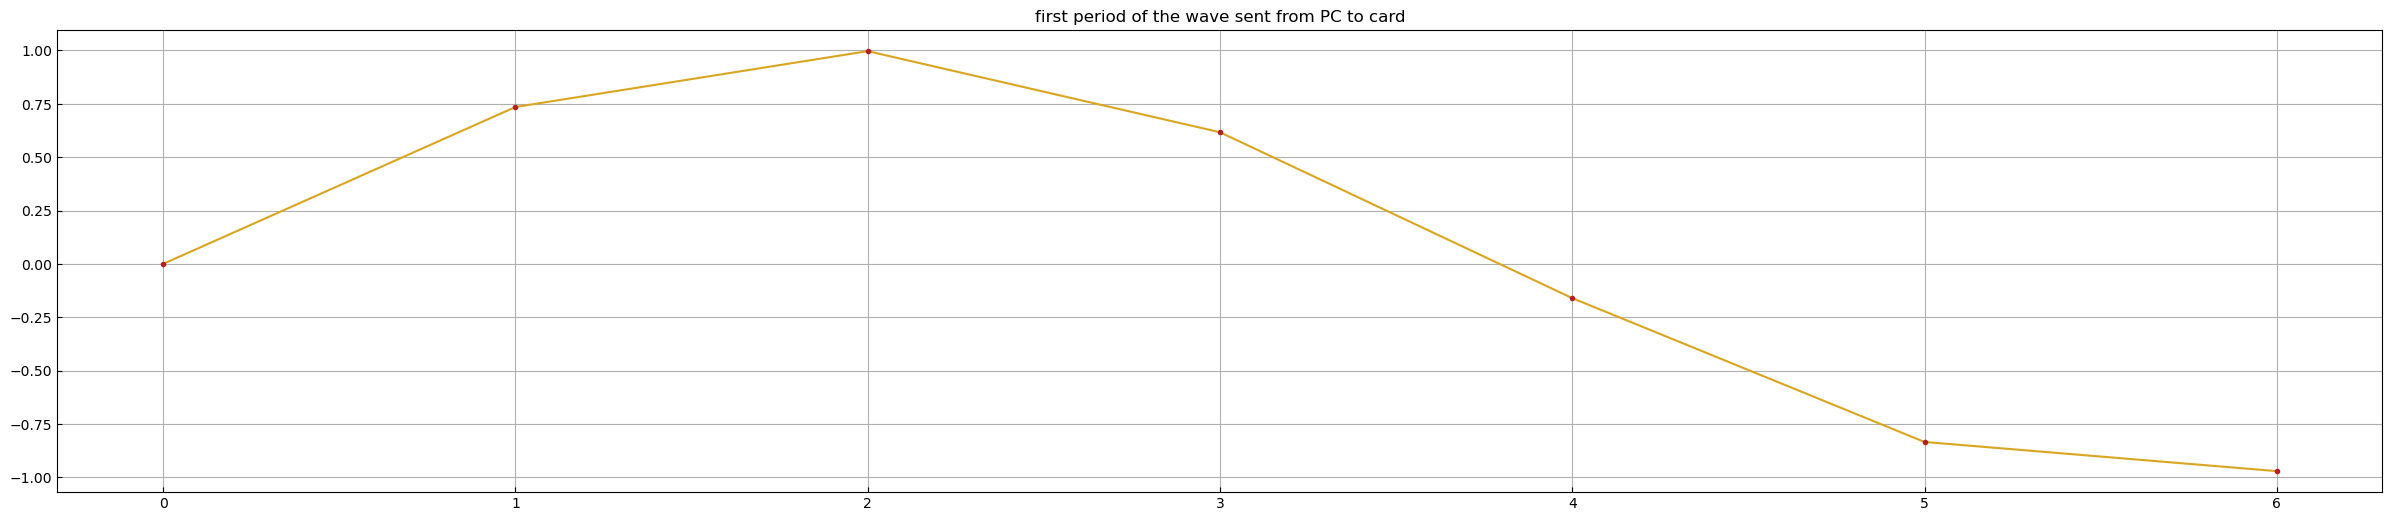

In [95]:
#rounded resolution, defined as the ratio between
resolution = wg.frequency_resolution(mem_size, sample_rate)
print(f'wave resolution: {resolution}')

#define vector of tones
tones_array = wg.tones_array(1, 82e6, 8e6) # was 78
print(f'frequencies: {tones_array * 1e-6} MHz')

#find resulting frequency and define sample rate
f_eq = np.gcd.reduce(tones_array.astype(np.int64))
print(f'resulting frequency (MCD): {f_eq*1e-6} MHz')

n_periods = f_eq/resolution
print(f'number of periods generated: {n_periods}')

# # this is used to have an idea  of the sample. It is not the wave that we send to the card, but just the first period of the wave
fig = plt.subplots(1, figsize = (30, 6))
plt.plot(wg.multi_tone(mem_size, sample_rate, tones_array, None, wg.kitayoshi_array(len(tones_array)))[:int((mem_size/n_periods))], marker = '.', mec = "firebrick", mfc = "firebrick", color = "goldenrod")
plt.grid()
plt.title('first period of the wave sent from PC to card')
plt.tick_params(axis="y",direction="in")
plt.tick_params(axis="x",direction="in")


In [96]:
#calculation of Crest Factor and Nyquist frequency
print(f"crest factor using Kitayoshi's algorithm: {wg.Crest_Factor(tones_array)}")

if sample_rate >= 2 * f_eq:
    print('Nyquist theorem is satisfied')
else:
    print('Nyquist theorem not satisfied')

crest factor using Kitayoshi's algorithm: 0.0
Nyquist theorem is satisfied


In [ ]:
final_amplitudes = None


SC._transfer_numpy_array_to_card(True, wg.multi_tone(mem_size, sample_rate, tones_array, final_amplitudes, wg.kitayoshi_array(len(tones_array)), True), True)

#damped array of tweezers
# amplitudes = np.array([1.0, 1.0, 1.0])
# tau = np.array([0, 10e3, 10e3])
# SC._transfer_numpy_array_to_card(True, wg.damped_multi_tone(mem_size, sample_rate, tones_array, amplitudes, tau))

#enable these if you want to use gate mode
# SC._enable_trigger()
# SC._start_and_enable_gate()
# SC._start_and_wait_timeout(0)


#multiple replay mode
# SC._start_and_enable_multiple_replay_mode(int(mem_size/2))
# SC._transfer_numpy_array_to_card(True, wg.multi_tone(mem_size, sample_rate, tones_array))

#enable these if you want to use trigger mode
# SC._enable_trigger()
# SC._start_and_enable_trigger()

#enable this if you want to use timeout mode
SC._start_and_wait_timeout(0)

In [ ]:
if False:
    SC._close()